<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/DL_WEEK11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement Auto Encoder model on MINIST dataset.


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2897 - val_loss: 0.2042
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1831 - val_loss: 0.1650
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1560 - val_loss: 0.1453
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1399 - val_loss: 0.1325
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1295 - val_loss: 0.1241
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1229 - val_loss: 0.1189
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1186 - val_loss: 0.1155
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1155 - val_loss: 0.1125
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1130 - val_loss: 0.1105
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1111 - val_loss: 0.1087
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1096 - val_loss: 0.1076
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

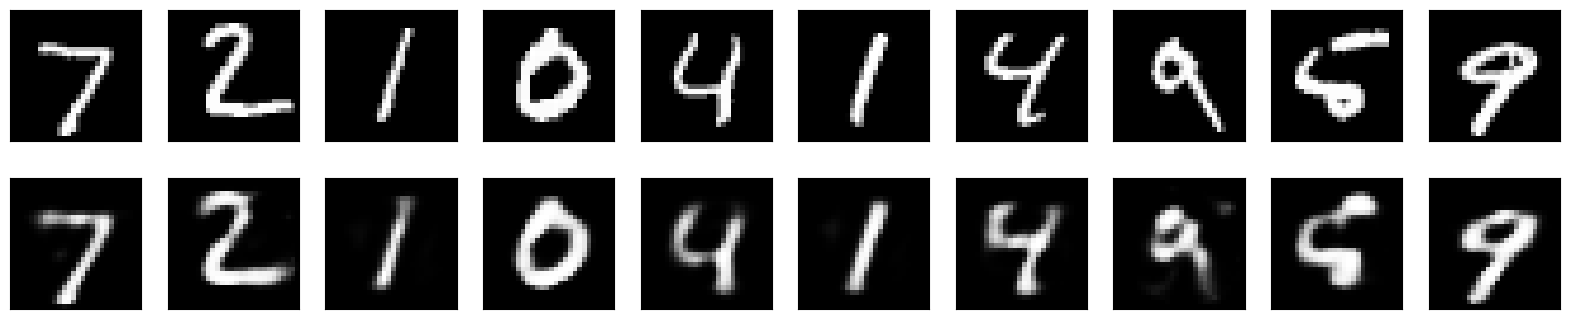

In [ ]:

import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
input_dim = 784  # 28x28 images
encoding_dim = 24  # Compressed representation
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
decoded_imgs = autoencoder.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2443 - val_loss: 0.1628
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1444 - val_loss: 0.1274
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.1190 - val_loss: 0.1086
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1040 - val_loss: 0.0973
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0947 - val_loss: 0.0900
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0884 - val_loss: 0.0851
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0841 - val_loss: 0.0815
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0812 - val_loss: 0.0791
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0791 - val_loss: 0.0775
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0777 - val_loss: 0.0764
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0767 - val_loss: 0.0756
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

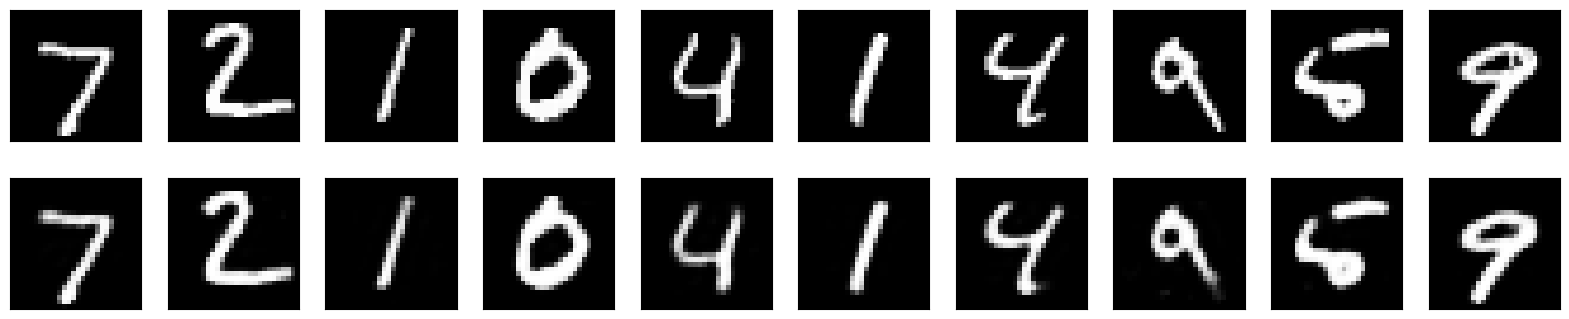

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
input_dim = 784  # 28x28 images
encoding_dim = 64  # Compressed representation
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
decoded_imgs = autoencoder.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.1851 - val_loss: 0.1109
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0972 - val_loss: 0.0857
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0815 - val_loss: 0.0766
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0750 - val_loss: 0.0726
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0718 - val_loss: 0.0703
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0700 - val_loss: 0.0689
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0688 - val_loss: 0.0679
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0679 - val_loss: 0.0672
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0673 - val_loss: 0.0667
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0668 - val_loss: 0.0663
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0664 - val_loss: 0.0659
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━

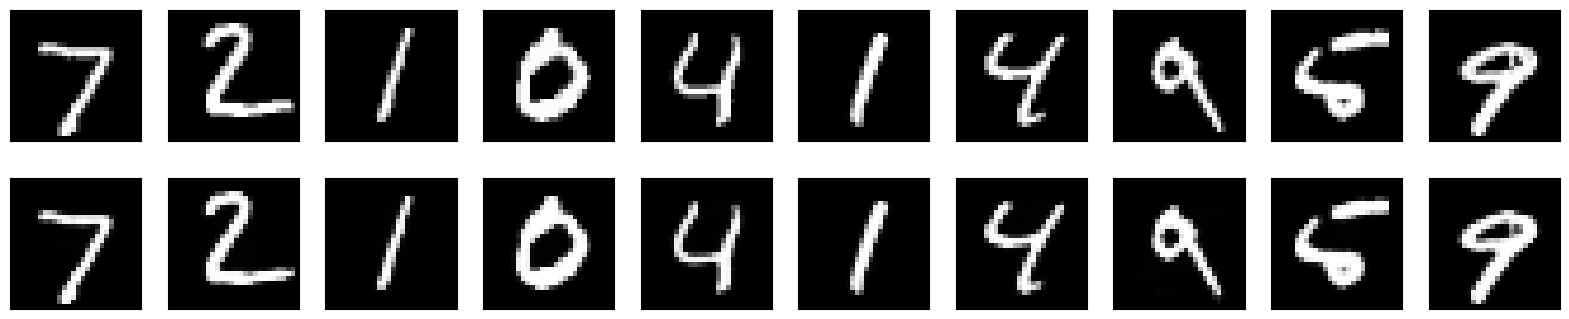

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
input_dim = 784  # 28x28 images
encoding_dim = 256  # Compressed representation
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
decoded_imgs = autoencoder.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

So as the encoding layer dim increases loss is decreasing but as we increase overfitting increases i.e model tries to memorize the data and not learning any features

**Undercomplete AE**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)
decoded_imgs = autoencoder.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.show()

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 403ms/step - loss: 0.1085 - val_loss: 0.0736
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 408ms/step - loss: 0.0723 - val_loss: 0.0709
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 208s 443ms/step - loss: 0.0695 - val_loss: 0.0682
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 245s 406ms/step - loss: 0.0683 - val_loss: 0.0671
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 432ms/step - loss: 0.0673 - val_loss: 0.0664
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 428ms/step - loss: 0.0667 - val_loss: 0.0659
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 429ms/step - loss: 0.0662 - val_loss: 0.0662
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 434ms/step - loss: 0.0657 - val_loss: 0.0652
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - loss: 0.0653 - val_loss: 0.0647
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 407ms/step - loss: 0.0650 - val_loss: 0.0644
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 407ms/step - loss: 0.0647 - val_loss: 0.0641
Epoch 12

**Overcomplete AE**

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
# Overcomplete AE with encoding_dim = 1024 (>784)
encoding_dim = 1024
input_layer = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

overcomplete_ae = Model(input_layer, decoded)
overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

overcomplete_ae.fit(x_train, x_train,
                    epochs=20,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, x_test))

decoded_imgs = overcomplete_ae.predict(x_test)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

**Undercomplete AE**: Compressed representation smaller than input (encoding_dim < input_dim)
Forces AE to learn most important features

**Overcomplete AE**: Compressed representation larger than input (encoding_dim > input_dim)
May memorize input, less useful for generalization

**ADVANTAGES OF Overcomplete AE**

Denoising: Learns meaningful features from noisy data instead of memorizing.

Pretraining: Captures rich patterns to initialize deep networks.

Sparse Feature Learning: With regularization, only important neurons activate.

High-Fidelity Reconstruction: Retains fine details for super-resolution or inpainting.

Undercomplete autoencoders compress the input into a lower-dimensional representation. It is observed that images can be compressed from 784 dimensions to around 64–128 dimensions while maintaining acceptable reconstruction quality. Further reduction (e.g., 16 or 32) leads to significant information loss and blurry outputs.

Overcomplete autoencoders use higher dimensions (e.g., 1024), resulting in near-perfect reconstruction. However, they may learn identity mapping and fail to extract meaningful features due to excessive capacity.